In [255]:
import pandas as pd

trades = {
    "Trade_ID": [1, 2, 3],
    "Product": ["Crude Oil", "Gold", "Natural Gas"],
    "Direction": ["Buy", "Sell", "Buy"],
    "Quantity": [100, 20, 50],
    "Trade_Price": [72.50, 3350.00, 3.20],
    "Current_Price": [75.00, 3300.00, 3.50]
}

df = pd.DataFrame(trades)

df

,Trade_ID,Product,Direction,Quantity,Trade_Price,Current_Price
0,1,Crude Oil,Buy,100,72.5,75.0
1,2,Gold,Sell,20,3350.0,3300.0
2,3,Natural Gas,Buy,50,3.2,3.5


In [256]:
df["PnL"] = (
    df["Current_Price"] - df["Trade_Price"]
) * df["Quantity"]

df

,Trade_ID,Product,Direction,Quantity,Trade_Price,Current_Price,PnL
0,1,Crude Oil,Buy,100,72.5,75.0,250.0
1,2,Gold,Sell,20,3350.0,3300.0,-1000.0
2,3,Natural Gas,Buy,50,3.2,3.5,15.0


In [257]:
total_pnl = df["PnL"].sum()

print(f"Total Portfolio PnL = £{total_pnl:.2f}")

Total Portfolio PnL = £-735.00


In [258]:
df[df["PnL"] > 0]

,Trade_ID,Product,Direction,Quantity,Trade_Price,Current_Price,PnL
0,1,Crude Oil,Buy,100,72.5,75.0,250.0
2,3,Natural Gas,Buy,50,3.2,3.5,15.0


In [259]:
df["PnL"] = df.apply(
    lambda row:
    (row["Current_Price"] - row["Trade_Price"]) * row["Quantity"]
    if row["Direction"] == "Buy"
    else
    (row["Trade_Price"] - row["Current_Price"]) * row["Quantity"],
    axis=1
)

df

,Trade_ID,Product,Direction,Quantity,Trade_Price,Current_Price,PnL
0,1,Crude Oil,Buy,100,72.5,75.0,250.0
1,2,Gold,Sell,20,3350.0,3300.0,1000.0
2,3,Natural Gas,Buy,50,3.2,3.5,15.0


In [260]:
total_pnl = df["PnL"].sum()

print(f"Total Portfolio PnL = £{total_pnl:.2f}")

Total Portfolio PnL = £1265.00


In [261]:
df["Status"] = df["PnL"].apply(
    lambda pnl: "Profit" if pnl > 0 else "Loss"
)

df

,Trade_ID,Product,Direction,Quantity,Trade_Price,Current_Price,PnL,Status
0,1,Crude Oil,Buy,100,72.5,75.0,250.0,Profit
1,2,Gold,Sell,20,3350.0,3300.0,1000.0,Profit
2,3,Natural Gas,Buy,50,3.2,3.5,15.0,Profit


In [262]:
best_trade = df.loc[df["PnL"].idxmax()]

best_trade

Trade_ID              2
Product            Gold
Direction          Sell
Quantity             20
Trade_Price      3350.0
Current_Price    3300.0
PnL              1000.0
Status           Profit
Name: 1, dtype: object

In [263]:
product_pnl = df.groupby("Product")["PnL"].sum()

product_pnl

Product
Crude Oil       250.0
Gold           1000.0
Natural Gas      15.0
Name: PnL, dtype: float64

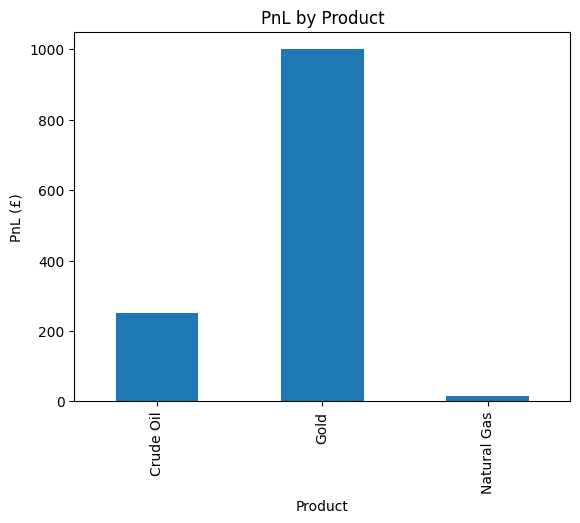

In [264]:
import matplotlib.pyplot as plt

product_pnl.plot(kind="bar")

plt.title("PnL by Product")
plt.xlabel("Product")
plt.ylabel("PnL (£)")

plt.show()

In [265]:
broker_data = {
    "Trade_ID": [1, 2, 3],
    "Broker_Quantity": [100, 19, 50]
}

broker_df = pd.DataFrame(broker_data)

broker_df

,Trade_ID,Broker_Quantity
0,1,100
1,2,19
2,3,50


In [266]:
reconciliation = pd.merge(
    df,
    broker_df,
    on="Trade_ID",
    how="left"
)

reconciliation

,Trade_ID,Product,Direction,Quantity,Trade_Price,Current_Price,PnL,Status,Broker_Quantity
0,1,Crude Oil,Buy,100,72.5,75.0,250.0,Profit,100
1,2,Gold,Sell,20,3350.0,3300.0,1000.0,Profit,19
2,3,Natural Gas,Buy,50,3.2,3.5,15.0,Profit,50


In [267]:
reconciliation["Quantity_Break"] = (
    reconciliation["Quantity"] != reconciliation["Broker_Quantity"]
)

reconciliation

,Trade_ID,Product,Direction,Quantity,Trade_Price,Current_Price,PnL,Status,Broker_Quantity,Quantity_Break
0,1,Crude Oil,Buy,100,72.5,75.0,250.0,Profit,100,False
1,2,Gold,Sell,20,3350.0,3300.0,1000.0,Profit,19,True
2,3,Natural Gas,Buy,50,3.2,3.5,15.0,Profit,50,False


In [268]:
breaks = reconciliation[
    reconciliation["Quantity_Break"] == True
]

breaks

,Trade_ID,Product,Direction,Quantity,Trade_Price,Current_Price,PnL,Status,Broker_Quantity,Quantity_Break
1,2,Gold,Sell,20,3350.0,3300.0,1000.0,Profit,19,True


In [269]:
reconciliation["Quantity_Difference"] = (
    reconciliation["Quantity"]
    - reconciliation["Broker_Quantity"]
)

reconciliation

,Trade_ID,Product,Direction,Quantity,Trade_Price,Current_Price,PnL,Status,Broker_Quantity,Quantity_Break,Quantity_Difference
0,1,Crude Oil,Buy,100,72.5,75.0,250.0,Profit,100,False,0
1,2,Gold,Sell,20,3350.0,3300.0,1000.0,Profit,19,True,1
2,3,Natural Gas,Buy,50,3.2,3.5,15.0,Profit,50,False,0


In [270]:
exception_report = reconciliation[
    reconciliation["Quantity_Break"] == True
][[
    "Trade_ID",
    "Product",
    "Direction",
    "Quantity",
    "Broker_Quantity",
    "Quantity_Difference",
    "PnL"
]]

exception_report

,Trade_ID,Product,Direction,Quantity,Broker_Quantity,Quantity_Difference,PnL
1,2,Gold,Sell,20,19,1,1000.0


In [271]:
exception_report.to_csv("exception_report.csv", index=False)

In [272]:
df.to_csv("trade_pnl_report.csv", index=False)

In [273]:
import sqlite3

connection = sqlite3.connect("trading_database.db")

df.to_sql("trades", connection, if_exists="replace", index=False)
broker_df.to_sql("broker_records", connection, if_exists="replace", index=False)

connection.close()

In [274]:
import sqlite3
import pandas as pd

connection = sqlite3.connect("trading_database.db")

query = """
SELECT *
FROM trades
"""

sql_results = pd.read_sql_query(query, connection)

sql_results

,Trade_ID,Product,Direction,Quantity,Trade_Price,Current_Price,PnL,Status
0,1,Crude Oil,Buy,100,72.5,75.0,250.0,Profit
1,2,Gold,Sell,20,3350.0,3300.0,1000.0,Profit
2,3,Natural Gas,Buy,50,3.2,3.5,15.0,Profit


In [275]:
connection = sqlite3.connect("trading_database.db")

query = """
SELECT *
FROM trades
WHERE PnL > 0
"""

profitable_trades = pd.read_sql_query(query, connection)

profitable_trades

,Trade_ID,Product,Direction,Quantity,Trade_Price,Current_Price,PnL,Status
0,1,Crude Oil,Buy,100,72.5,75.0,250.0,Profit
1,2,Gold,Sell,20,3350.0,3300.0,1000.0,Profit
2,3,Natural Gas,Buy,50,3.2,3.5,15.0,Profit


In [276]:
query = """
SELECT 
    trades.Trade_ID,
    trades.Product,
    trades.Direction,
    trades.Quantity AS Internal_Quantity,
    broker_records.Broker_Quantity,
    trades.Quantity - broker_records.Broker_Quantity AS Quantity_Difference,
    trades.PnL
FROM trades
JOIN broker_records
ON trades.Trade_ID = broker_records.Trade_ID
WHERE trades.Quantity != broker_records.Broker_Quantity
"""

sql_breaks = pd.read_sql_query(query, connection)

sql_breaks

,Trade_ID,Product,Direction,Internal_Quantity,Broker_Quantity,Quantity_Difference,PnL
0,2,Gold,Sell,20,19,1,1000.0


## Project Summary

This project demonstrates the use of Python, SQL, pandas and matplotlib to simulate a commodity trading operations workflow.

Key functionality includes:

- Trade-level PnL calculation
- Portfolio-level performance analysis
- Product-level reporting
- Trade reconciliation against broker records
- Quantity break detection
- Exception report generation
- SQL database storage and querying
- Data visualisation

The project successfully identified a quantity break between internal and broker records and generated automated reports to support operational investigations.

In [281]:
print("=== Trading Operations Summary ===")
print(f"Total Portfolio PnL: £{df['PnL'].sum():.2f}")
print(f"Number of Trades: {len(df)}")
print(f"Number of Trade Breaks: {reconciliation['Quantity_Break'].sum()}")
print(f"Best Trade: {best_trade['Product']}")
print(f"Best Trade PnL: £{best_trade['PnL']:.2f}")

=== Trading Operations Summary ===
Total Portfolio PnL: £1265.00
Number of Trades: 3
Number of Trade Breaks: 1
Best Trade: Gold
Best Trade PnL: £1000.00


# Commodity Trading Operations & Reconciliation Dashboard

## Overview

This project simulates a commodity trading operations workflow using Python, SQL and pandas.

The dashboard performs:

- Trade-level PnL calculations
- Portfolio-level PnL analysis
- Product performance analysis
- Trade reconciliation against broker records
- Quantity break detection
- Exception report generation
- SQL database storage and querying
- Data visualisation using matplotlib

## Technologies Used

- Python
- Pandas
- SQLite
- SQL
- Matplotlib

## Key Outputs

- Total Portfolio PnL
- Product-level PnL analysis
- Trade break identification
- Exception reports
- CSV exports
- SQL-based reconciliation checks